In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_test_2014_05_12.csv" "/content/master_long_hourly_test_2014_05_12.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_train_2012_2013.csv" "/content/master_long_hourly_train_2012_2013.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_validation_2014_01_04.csv" "/content/master_long_hourly_validation_2014_01_04.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/calendar_features_hourly.csv" "/content/calendar_features_hourly.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/user_cluster_mapping.csv" "/content/user_cluster_mapping.csv"

In [3]:
from pathlib import Path

# Input files — produced by preprocessing + data-split teammate
TRAIN_PATH    = "/content/master_long_hourly_train_2012_2013.csv"
VAL_PATH      = "/content/master_long_hourly_validation_2014_01_04.csv"
TEST_PATH     = "/content/master_long_hourly_test_2014_05_12.csv"
CALENDAR_PATH = "/content/calendar_features_hourly.csv"
MAPPING_PATH  = "/content/user_cluster_mapping.csv"   # cluster assignments

# Output
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Model
SEASON_LENGTH = 24  # hourly data → daily seasonality

In [4]:
# IMPORTS
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import glob

In [5]:
# LOAD CLIENTS
# Reuse the same clients as SARIMAX so metrics are directly comparable
# selected = pd.read_csv(SELECTED_CLIENTS_PATH)['client_id'].tolist()
# print(f'Using {len(selected)} clients: {selected}')

# Use all clients from the training data instead of sampling
df_tmp = pd.read_csv(TRAIN_PATH)
selected = df_tmp['client_id'].unique().tolist()
print(f'Using all {len(selected)} clients from training data')

Using all 156 clients from training data


In [6]:
# PREPARE DATA
# Prophet has built-in daily, weekly, and yearly seasonality via Fourier series,
# so cyclic encodings (hour_sin/cos, dow_sin/cos, etc.) would be redundant.
# is_weekend is kept as an extra regressor - it captures a structural break
# (flat vs. peaked consumption) that weekly seasonality alone may smooth over.
EXOG_COLS = ['is_weekend']

calendar = pd.read_csv(CALENDAR_PATH, parse_dates=['timestamp'])


def load_split(path, clients, calendar, exog_cols):
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df = df[df['client_id'].isin(clients)].copy()
    df = df.merge(calendar[['timestamp'] + exog_cols], on='timestamp', how='left')
    df = df.rename(columns={'client_id': 'unique_id', 'timestamp': 'ds'})
    return df.sort_values(['unique_id', 'ds']).reset_index(drop=True)


train = load_split(TRAIN_PATH, selected, calendar, EXOG_COLS)
val   = load_split(VAL_PATH,   selected, calendar, EXOG_COLS)
test  = load_split(TEST_PATH,  selected, calendar, EXOG_COLS)

print(f"train : {train.shape}  {train['ds'].min()} -> {train['ds'].max()}")
print(f"val   : {val.shape}    {val['ds'].min()} -> {val['ds'].max()}")
print(f"test  : {test.shape}   {test['ds'].min()} -> {test['ds'].max()}")

train : (2721888, 4)  2012-01-01 00:00:00 -> 2013-12-31 23:00:00
val   : (445536, 4)    2014-01-01 00:00:00 -> 2014-04-30 23:00:00
test  : (913536, 4)   2014-05-01 00:00:00 -> 2014-12-31 23:00:00


In [7]:
# CLUSTER AGGREGATION
# Load cluster assignments produced by the clustering pipeline
mapping      = pd.read_csv(MAPPING_PATH)
cluster_map  = mapping[mapping["cluster_id"] != -1].set_index("user_id")["cluster_id"]
outlier_users = mapping[mapping["cluster_id"] == -1]["user_id"].tolist()


def aggregate_to_clusters(df, cluster_map, outlier_users, exog_cols):
    """Average all users in a cluster into one series per cluster.
    Outlier users (cluster_id == -1) are kept as individual series.
    """
    rows = []
    for cluster_id, users in cluster_map.groupby(cluster_map):
        cluster_users = users.index.tolist()
        cluster_df = df[df["unique_id"].isin(cluster_users)]
        agg = (
            cluster_df
            .groupby("ds")[["y"] + exog_cols]
            .mean()
            .reset_index()
        )
        agg["unique_id"] = f"cluster_{int(cluster_id)}"
        rows.append(agg)
    for user in outlier_users:
        rows.append(df[df["unique_id"] == user].copy())
    return (
        pd.concat(rows, ignore_index=True)
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )


# Compute per-user scale factor relative to its cluster mean (training data only)
user_means = train.groupby("unique_id")["y"].mean()
user_proportions = {}
for cluster_id, users in cluster_map.groupby(cluster_map):
    cluster_users  = users.index.tolist()
    cluster_mean   = user_means[cluster_users].mean()
    for user in cluster_users:
        user_proportions[user] = float(user_means[user] / cluster_mean)
for user in outlier_users:
    user_proportions[user] = 1.0  # outliers are their own series

train_agg = aggregate_to_clusters(train, cluster_map, outlier_users, EXOG_COLS)
val_agg   = aggregate_to_clusters(val,   cluster_map, outlier_users, EXOG_COLS)
test_agg  = aggregate_to_clusters(test,  cluster_map, outlier_users, EXOG_COLS)

print(f"Training on {train_agg['unique_id'].nunique()} series: {sorted(train_agg['unique_id'].unique())}")

Training on 10 series: ['MT_124', 'MT_132', 'MT_156', 'MT_158', 'MT_159', 'MT_161', 'MT_162', 'MT_163', 'cluster_0', 'cluster_1']


In [8]:
# FORECAST (Train & Validation)
def predict_split(models, split_df, exog_cols):
    preds = []
    for uid, grp in split_df.groupby('unique_id'):
        if uid not in models:
            continue
        m = models[uid]
        future = grp[['ds'] + exog_cols].copy()
        forecast = m.predict(future)[['ds', 'yhat']].rename(columns={'yhat': 'Prophet'})
        forecast['unique_id'] = uid
        preds.append(forecast)
    return pd.concat(preds, ignore_index=True)


# DISAGGREGATE cluster forecasts back to individual users
def disaggregate(preds_df, user_proportions, cluster_map, outlier_users, pred_col):
    """Scale cluster-level forecasts back to individual user level."""
    rows = []
    for cluster_id, users in cluster_map.groupby(cluster_map):
        cluster_uid = f"cluster_{int(cluster_id)}"
        cluster_fc  = preds_df[preds_df["unique_id"] == cluster_uid][["ds", pred_col]].copy()
        for user in users.index:
            user_fc = cluster_fc.copy()
            user_fc[pred_col] = user_fc[pred_col] * user_proportions[user]
            user_fc["unique_id"] = user
            rows.append(user_fc)
    for user in outlier_users:
        rows.append(preds_df[preds_df["unique_id"] == user][["unique_id", "ds", pred_col]].copy())
    return pd.concat(rows, ignore_index=True)


# EVALUATION METRICS
def compute_metrics(df, target_col='y', pred_col='Prophet'):
    y    = df[target_col].values
    yhat = df[pred_col].values
    pos  = y > 0
    mse  = np.mean((y - yhat) ** 2)
    mae  = np.mean(np.abs(y - yhat))
    mape = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float('nan')
    wape = np.sum(np.abs(y - yhat)) / np.sum(np.abs(y))
    return {'MSE': round(mse, 4), 'MAE': round(mae, 4), 'MAPE': round(mape, 4), 'WAPE': round(wape, 4)}


def per_client_metrics(df, target_col='y', pred_col='Prophet'):
    rows = []
    for uid, grp in df.groupby('unique_id'):
        rows.append({'client_id': uid, **compute_metrics(grp, target_col, pred_col)})
    rows.append({'client_id': 'OVERALL', **compute_metrics(df, target_col, pred_col)})
    return pd.DataFrame(rows)

In [9]:
# TRAIN PROPHET
# One Prophet model is fit per client - Prophet is not a panel model.
# Seasonality mode: additive works well unless consumption variance scales with level.
def fit_prophet(df, exog_cols):
    models = {}
    for uid, grp in df.groupby('unique_id'):
        m = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=True,
            seasonality_mode='additive',
        )
        for col in exog_cols:
            m.add_regressor(col)
        m.fit(grp[['ds', 'y'] + exog_cols])
        models[uid] = m
        print(f'  Fitted: {uid}')
    return models

In [10]:
print('Training Prophet models...')
prophet_models = fit_prophet(train_agg, EXOG_COLS)

# Save one file per cluster / outlier series
for uid, model in prophet_models.items():
    joblib.dump(model, MODEL_DIR / f'prophet_val_{uid}.joblib')
print(f'Training complete. {len(prophet_models)} models saved → {MODEL_DIR}/')

Training Prophet models...
  Fitted: MT_124
  Fitted: MT_132
  Fitted: MT_156
  Fitted: MT_158
  Fitted: MT_159
  Fitted: MT_161
  Fitted: MT_162
  Fitted: MT_163
  Fitted: cluster_0
  Fitted: cluster_1
Training complete. 10 models saved → models/


In [11]:
# LOAD SAVED MODELS
# Use this to load pre-trained models instead of re-running the training cell.

model_files = sorted(glob.glob(str(MODEL_DIR / 'prophet_val_*.joblib')))
if model_files:
    prophet_models = {
        Path(f).stem.replace('prophet_val_', ''): joblib.load(f)
        for f in model_files
    }
    print(f"Loaded {len(prophet_models)} models: {sorted(prophet_models.keys())}")
else:
    print("No saved models found. Please run the training cell.")

Loaded 10 models: ['MT_124', 'MT_132', 'MT_156', 'MT_158', 'MT_159', 'MT_161', 'MT_162', 'MT_163', 'cluster_0', 'cluster_1']


In [12]:
print('Predicting on Training set...')
train_preds_agg = predict_split(prophet_models, train_agg, EXOG_COLS)
train_preds     = disaggregate(train_preds_agg, user_proportions, cluster_map, outlier_users, 'Prophet')
train_eval      = train[['unique_id', 'ds', 'y']].merge(train_preds, on=['unique_id', 'ds'])

print('Predicting on Validation set...')
val_preds_agg = predict_split(prophet_models, val_agg, EXOG_COLS)
val_preds     = disaggregate(val_preds_agg, user_proportions, cluster_map, outlier_users, 'Prophet')
val_eval      = val[['unique_id', 'ds', 'y']].merge(val_preds, on=['unique_id', 'ds'])

print(val_eval.head())

Predicting on Training set...
Predicting on Validation set...
  unique_id                  ds          y     Prophet
0    MT_124 2014-01-01 00:00:00  95.693780  305.275095
1    MT_124 2014-01-01 01:00:00  83.732056  280.589067
2    MT_124 2014-01-01 02:00:00  82.535890  238.627889
3    MT_124 2014-01-01 03:00:00  82.535890  181.716850
4    MT_124 2014-01-01 04:00:00  63.397133  124.410928


In [13]:
train_metrics = per_client_metrics(train_eval)
print('-- Training metrics --')
print(train_metrics.to_string(index=False))
print('\n')

val_metrics = per_client_metrics(val_eval)
print('-- Validation metrics --')
print(val_metrics.to_string(index=False))

-- Training metrics --
client_id          MSE       MAE      MAPE   WAPE
   MT_124    1947.1266   33.3640   16.0609 0.1217
   MT_132     125.7129    8.1900   37.7374 0.5826
   MT_156     368.5904   15.7709   42.4902 0.2160
   MT_158     946.6936   25.2073   69.9321 0.3703
   MT_159     682.1916   21.2088   71.6243 0.3985
   MT_161   38557.1585  137.1248   13.6576 0.0792
   MT_162    5632.1216   59.7747   32.1880 0.2145
   MT_163   41434.2622  152.2945    6.9435 0.0661
   MT_166   26744.4574  127.1006   12.0433 0.1005
   MT_168     627.4656   18.6124   14.2290 0.1374
   MT_169      27.3960    4.0545   11.0965 0.1036
   MT_171    1039.0077   25.3978   11.1562 0.1037
   MT_172     484.9397   17.1737   15.9923 0.1424
   MT_174     525.7664   17.6610   12.9068 0.1196
   MT_175     918.9053   23.4381   16.2849 0.1440
   MT_176     203.3709   11.2143   14.8013 0.1333
   MT_180     655.0975   20.0193   13.3526 0.1276
   MT_182      48.4294    5.5699   11.6880 0.1068
   MT_183     228.4966   11

In [14]:
# TEST EVALUATION
# Retrain on full train+val, then predict on the held-out test set
train_val     = pd.concat([train, val], ignore_index=True).sort_values(['unique_id', 'ds'])
train_val_agg = aggregate_to_clusters(train_val, cluster_map, outlier_users, EXOG_COLS)

print('Retraining on train+val...')
prophet_models_final = fit_prophet(train_val_agg, EXOG_COLS)

# Save one file per cluster / outlier series
for uid, model in prophet_models_final.items():
    joblib.dump(model, MODEL_DIR / f'prophet_final_{uid}.joblib')
print(f'Final models saved → {MODEL_DIR}/')

test_preds_agg = predict_split(prophet_models_final, test_agg, EXOG_COLS)
test_preds     = disaggregate(test_preds_agg, user_proportions, cluster_map, outlier_users, 'Prophet')
test_eval      = test[['unique_id', 'ds', 'y']].merge(test_preds, on=['unique_id', 'ds'])

test_metrics = per_client_metrics(test_eval)
print('-- Test metrics --')
print(test_metrics.to_string(index=False))

Retraining on train+val...
  Fitted: MT_124
  Fitted: MT_132
  Fitted: MT_156
  Fitted: MT_158
  Fitted: MT_159
  Fitted: MT_161
  Fitted: MT_162
  Fitted: MT_163
  Fitted: cluster_0
  Fitted: cluster_1
Final models saved → models/
-- Test metrics --
client_id          MSE       MAE    MAPE   WAPE
   MT_124 2.510190e+03   38.6452 18.4231 0.1287
   MT_132 1.061571e+02    6.9819 36.2030 0.4609
   MT_156 4.393134e+02   16.7491 24.4355 0.1886
   MT_158 7.828278e+02   21.7968 37.5757 0.2779
   MT_159 8.163636e+02   22.9672 90.0600 0.5358
   MT_161 1.500670e+05  344.9311 24.5209 0.2200
   MT_162 5.296578e+03   57.3423 32.4842 0.2115
   MT_163 1.170333e+05  276.7006 10.8295 0.1107
   MT_166 2.876089e+04  133.3959 12.0925 0.1033
   MT_168 6.121830e+02   20.1492 16.9262 0.1505
   MT_169 2.672300e+01    4.0736 10.9227 0.0967
   MT_171 2.125665e+03   39.1270 18.4568 0.1658
   MT_172 6.438331e+02   20.3964 18.5719 0.1669
   MT_174 6.697520e+02   19.2145 14.6794 0.1170
   MT_175 1.188238e+03   25.5

In [15]:
PRED_COL = "Prophet"

# Equal-size test periods (1464 hours = 61 days each)
TEST_PERIODS = [
    {"period_id": 1, "label": "Late Spring",     "start": "2014-05-01", "end": "2014-06-30"},
    {"period_id": 2, "label": "Summer",           "start": "2014-07-01", "end": "2014-08-30"},
    {"period_id": 3, "label": "Early Fall",       "start": "2014-08-31", "end": "2014-10-31"},
    {"period_id": 4, "label": "Late Fall/Winter", "start": "2014-11-01", "end": "2014-12-31"},
]


def _period_mask(df, start, end):
    s = pd.Timestamp(start)
    e = pd.Timestamp(end) + pd.Timedelta(hours=23)
    return (df["ds"] >= s) & (df["ds"] <= e)


def period_mape(df, start, end, pred_col):
    """Overall MAPE (0-100) for a time period across all users."""
    sub = df[_period_mask(df, start, end)]
    y, yhat = sub["y"].values, sub[pred_col].values
    pos = y > 0
    return float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")


def per_user_mapes_period(df, start, end, pred_col):
    """List of per-user MAPEs (0-100) for a time period (used for box plot)."""
    sub = df[_period_mask(df, start, end)]
    mapes = []
    for _, grp in sub.groupby("unique_id"):
        y, yhat = grp["y"].values, grp[pred_col].values
        pos = y > 0
        if pos.sum() > 0:
            mapes.append(float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100))
    return mapes

In [16]:
# ── MAPE table ────────────────────────────────────────────────────────────────
print(f"{'P':<4} {'Label':<20} {'Dates':<28} {'MAPE (0-100)':>12}")
print("─" * 68)
box_data, box_labels = [], []
for p in TEST_PERIODS:
    mape  = period_mape(test_eval, p["start"], p["end"], PRED_COL)
    mapes = per_user_mapes_period(test_eval, p["start"], p["end"], PRED_COL)
    box_data.append(mapes)
    box_labels.append(f"P{p['period_id']}: {p['label']}\n{p['start']} – {p['end']}")
    print(f"  {p['period_id']}  {p['label']:<20} {p['start']} – {p['end']}   {mape:>8.2f}%")

P    Label                Dates                        MAPE (0-100)
────────────────────────────────────────────────────────────────────
  1  Late Spring          2014-05-01 – 2014-06-30      16.34%
  2  Summer               2014-07-01 – 2014-08-30      22.00%
  3  Early Fall           2014-08-31 – 2014-10-31      18.44%
  4  Late Fall/Winter     2014-11-01 – 2014-12-31      21.52%


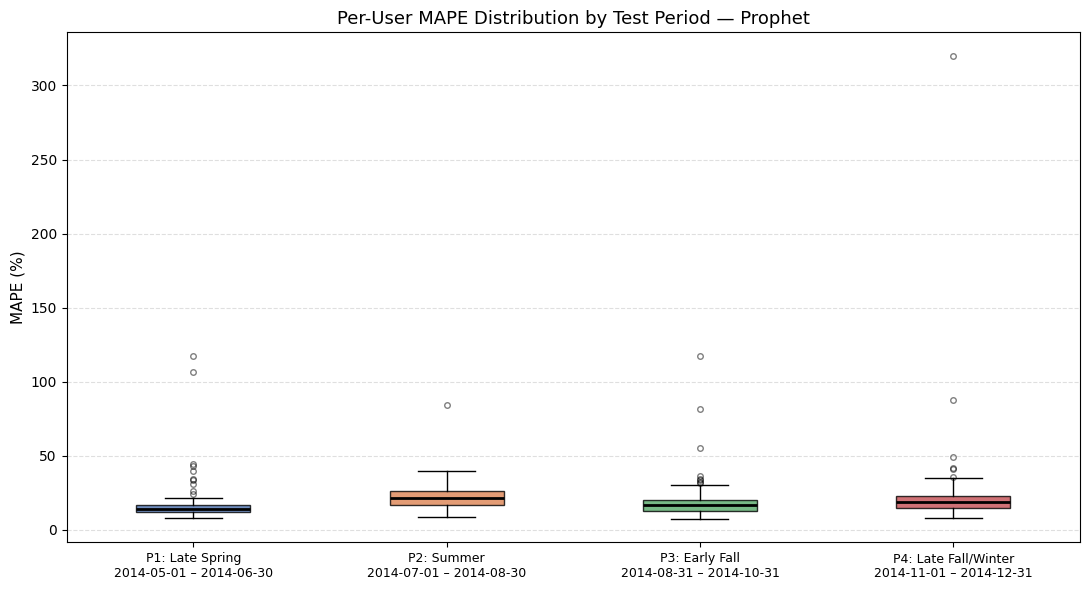

In [17]:
# ── Box plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(
    box_data,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(TEST_PERIODS) + 1))
ax.set_xticklabels(box_labels, fontsize=9)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_title(f"Per-User MAPE Distribution by Test Period — {PRED_COL}", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / f"test_period_boxplot_{PRED_COL.lower()}.png", dpi=150)
plt.show()

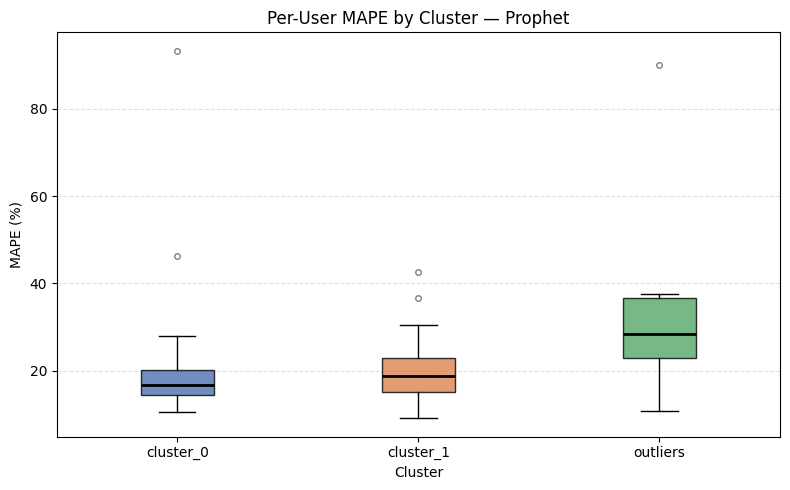

In [18]:
# BOX PLOT: Per-User MAPE by Cluster — Prophet

# Map each user to its cluster label
user_to_cluster = {}
for cluster_id, users in cluster_map.groupby(cluster_map):
    for user in users.index:
        user_to_cluster[user] = f"cluster_{int(cluster_id)}"
for user in outlier_users:
    user_to_cluster[user] = "outliers"

# Compute per-user MAPE over the full test period
per_user_mapes = {}
for uid, grp in test_eval.groupby("unique_id"):
    y, yhat = grp["y"].values, grp[PRED_COL].values
    pos = y > 0
    mape_u = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
    per_user_mapes[uid] = mape_u

# Group MAPEs by cluster
cluster_labels = sorted(set(user_to_cluster.values()))
box_data = []
for label in cluster_labels:
    users_in = [u for u, c in user_to_cluster.items() if c == label]
    mapes    = [per_user_mapes[u] for u in users_in
                if u in per_user_mapes and not np.isnan(per_user_mapes[u])]
    box_data.append(mapes)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    box_data, labels=cluster_labels, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
)
colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title(f"Per-User MAPE by Cluster — {PRED_COL}")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Cluster")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / f"cluster_boxplot_{PRED_COL.lower()}.png", dpi=150)
plt.show()

In [19]:
!zip -r Prophet_models.zip models/

from google.colab import files
files.download('Prophet_models.zip')

  adding: models/ (stored 0%)
  adding: models/prophet_final_MT_159.joblib (deflated 60%)
  adding: models/prophet_val_MT_161.joblib (deflated 59%)
  adding: models/prophet_final_MT_162.joblib (deflated 60%)
  adding: models/prophet_final_MT_158.joblib (deflated 60%)
  adding: models/prophet_final_cluster_1.joblib (deflated 51%)
  adding: models/prophet_final_MT_156.joblib (deflated 59%)
  adding: models/test_period_boxplot_prophet.png (deflated 23%)
  adding: models/prophet_final_MT_124.joblib (deflated 62%)
  adding: models/prophet_val_MT_156.joblib (deflated 59%)
  adding: models/prophet_val_MT_132.joblib (deflated 65%)
  adding: models/prophet_final_MT_132.joblib (deflated 64%)
  adding: models/prophet_val_cluster_1.joblib (deflated 51%)
  adding: models/prophet_final_cluster_0.joblib (deflated 51%)
  adding: models/prophet_final_MT_163.joblib (deflated 59%)
  adding: models/prophet_final_MT_161.joblib (deflated 60%)
  adding: models/prophet_val_MT_159.joblib (deflated 60%)
  addin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>